In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("../data/healthcare_dataset.csv")

In [4]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Hospital Stay Days
0,30,1,5,2,2024-01-31,1,18856.281306,2,2024-02-02,3,2,2
1,62,1,0,5,2019-08-20,3,33643.327287,1,2019-08-26,1,1,6
2,76,0,1,5,2022-09-22,0,27955.096079,1,2022-10-07,0,2,15
3,28,0,6,3,2020-11-18,3,37909.782410,0,2020-12-18,1,0,30
4,43,0,2,2,2022-09-19,0,14238.317814,2,2022-10-09,4,0,20


In [5]:
X = df.drop('Test Results', axis=1)

y = df['Test Results']

In [11]:
df = df.drop(
    ['Date of Admission','Discharge Date'],
    axis=1
)

In [12]:
X = df.drop('Test Results', axis=1)
y = df['Test Results']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = model.predict(X_test_scaled)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4376576576576577


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.45      0.44      3754
           1       0.43      0.42      0.43      3617
           2       0.45      0.44      0.44      3729

    accuracy                           0.44     11100
   macro avg       0.44      0.44      0.44     11100
weighted avg       0.44      0.44      0.44     11100



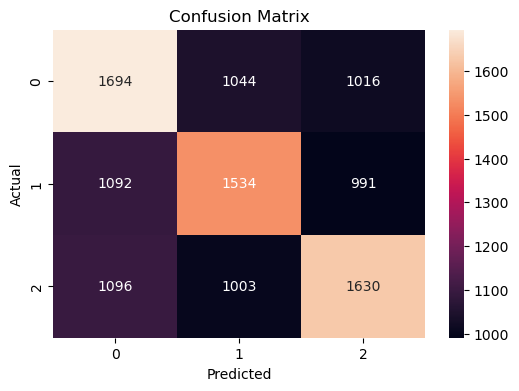

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(X_test_scaled)

In [21]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.33603603603603605


In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_scaled,
    y_train
)

dt_pred = dt_model.predict(X_test_scaled)

In [23]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.40621621621621623


In [25]:
import pickle

In [26]:
with open("../models/healthcare_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [27]:
with open("../models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [28]:
X.columns

Index(['Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Insurance Provider', 'Billing Amount', 'Admission Type', 'Medication',
       'Hospital Stay Days'],
      dtype='object')